# L3 Cavity with Conical Holes — Fabrication Taper Study
During dry etching (RIE/ICP), hole sidewalls can develop a slight taper,
producing cone-shaped holes — wider at the top (etch entry) and narrower at
the bottom. This notebook models the effect on the L3 cavity Q-factor using
a staircase approximation (multiple thin slab sub-layers with varying radii).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import legume
from legume import Circle, Ring

## Band structure of the perfect PhC (unit cell)

Bandgap: 0.2489 – 0.3274,  centre f_target = 0.2882


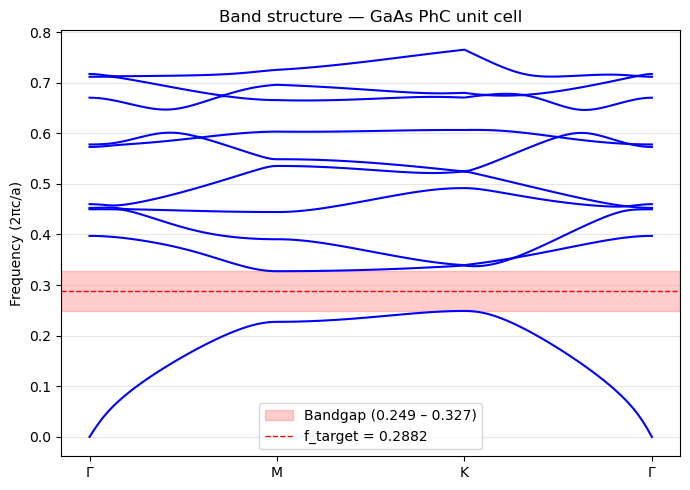

In [3]:
# ── Physical parameters ─────────────────────────────────────────────────────
a_nm = 250              # lattice constant in nm
ra = 75 / a_nm          # hole radius in units of a
dslab = 170 / a_nm      # slab thickness in units of a
n_slab = 3.46           # refractive index (GaAs)
n_oxide = 1.72          # refractive index (oxide)
eps_oxide = n_oxide**2

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=dslab, eps_b=n_slab**2)
phc_unit.add_shape(Circle(x_cent=0, y_cent=0, r=ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=3.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f'Bandgap: {f_lb:.4f} \u2013 {f_ub:.4f},  centre f_target = {f_target:.4f}')

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} \u2013 {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['\u0393', 'M', 'K', '\u0393'])
ax.set_ylabel('Frequency (2\u03c0c/a)')
ax.set_title('Band structure \u2014 GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ── Supercell parameters ───────────────────────────────────────────────────
Nx, Ny = 16, 10

# Initialize supercell lattice
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Build hole positions in one quadrant (L3: skip ix=0,1 at iy=0)
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Optimized end-hole shift (from autograd optimization notebook)
dx_opt = 0.17964
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = dx_opt  # ic=0 -> end holes at (+-2, 0)

print(f'nc = {nc} holes per quadrant')
print(f'Optimized end-hole shift: dx[0] = {dx_opt}a = {dx_opt * a_nm:.1f} nm')

nc = 52 holes per quadrant
Optimized end-hole shift: dx[0] = 0.17964a = 44.9 nm


In [5]:
import os
from datetime import datetime

SAVE_DATA = True

def save_sweep(name, arrays_dict, **extra_params):
    """Save sweep results to a timestamped folder in data/.

    Parameters
    ----------
    name : str
        Short sweep name (used in folder name).
    arrays_dict : dict
        {label: np.array} — each array is saved as a .npy file.
    **extra_params :
        Sweep-specific parameters to log in info.txt.
    """
    if not SAVE_DATA:
        return
    timestamp = datetime.now().strftime('%Y-%m-%d_%H%M%S')
    folder = os.path.join('data', f'{timestamp}_{name}')
    os.makedirs(folder, exist_ok=True)

    # Save arrays
    for label, arr in arrays_dict.items():
        np.save(os.path.join(folder, f'{label}.npy'), np.asarray(arr))

    # Write info.txt
    with open(os.path.join(folder, 'info.txt'), 'w') as f:
        f.write(f'Sweep: {name}\n')
        f.write(f'Date: {timestamp}\n\n')

        f.write('--- Physical parameters ---\n')
        f.write(f'a_nm = {a_nm}\n')
        f.write(f'ra = {ra:.4f} ({ra * a_nm:.1f} nm)\n')
        f.write(f'dslab = {dslab:.4f} ({dslab * a_nm:.1f} nm)\n')
        f.write(f'n_slab = {n_slab}\n\n')

        f.write('--- Supercell ---\n')
        f.write(f'Nx = {Nx}, Ny = {Ny}\n')
        f.write(f'nc = {nc}\n')
        f.write(f'dx_opt = {dx_opt} ({dx_opt * a_nm:.1f} nm)\n\n')

        f.write('--- GME settings ---\n')
        f.write(f'gmax = {gmax}\n')
        f.write(f'truncate_g = {truncate_g}\n')
        f.write(f'numeig = 10\n')
        f.write(f'gmode_inds = [0]\n\n')

        f.write('--- Bandgap ---\n')
        f.write(f'f_lb = {f_lb:.6f}\n')
        f.write(f'f_ub = {f_ub:.6f}\n')
        f.write(f'f_target = {f_target:.6f}\n')
        f.write(f'f_base = {f_base:.6f}\n')
        f.write(f'Q_base = {Q_base:.1f}\n\n')

        f.write('--- Sweep-specific parameters ---\n')
        for k, v in extra_params.items():
            f.write(f'{k} = {v}\n')

        f.write(f'\n--- Saved arrays ---\n')
        for label in arrays_dict:
            f.write(f'{label}.npy\n')

    print(f'Results saved to {folder}/')

## Conical cavity builder

In [6]:
def cavity_conical(taper_angle_deg, n_slices=10, r_nm=None):
    """Build an L3 cavity with conical (tapered) holes.

    Uses a staircase approximation: the slab is divided into n_slices
    sub-layers, each with a linearly varying hole radius.

    The taper is one-sided (realistic RIE profile):
      - r_top = ra (nominal radius, at etch entry / top surface)
      - r_bottom = ra - dslab * tan(taper_angle)

    Parameters
    ----------
    taper_angle_deg : float
        Sidewall taper angle in degrees, measured from vertical.
        0 = perfectly vertical walls (no taper).
    n_slices : int
        Number of sub-layers for the staircase approximation.
    r_nm : float or None, optional
        Hole radius in nm. If None, uses the global `ra` (75 nm default).
    """
    r_a = (r_nm / a_nm) if r_nm is not None else ra

    taper_rad = np.radians(taper_angle_deg)
    r_top = r_a
    r_bottom = r_a - dslab * np.tan(taper_rad)

    if r_bottom <= 0:
        raise ValueError(
            f'Taper too large: r_bottom = {r_bottom*a_nm:.1f} nm <= 0 '
            f'(angle = {taper_angle_deg} deg)')

    d_slice = dslab / n_slices
    phc = legume.PhotCryst(lattice)

    # Add sub-layers from top to bottom
    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice  # distance from top surface
        frac = z_center / dslab
        r_k = r_top * (1 - frac) + r_bottom * frac  # linear interpolation

        phc.add_layer(d=d_slice, eps_b=n_slab**2)

        for ic in range(nc):
            yc = yp[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))

            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_k), layer=k)

    return phc


# Print radius variation for reference
print('Taper angle -> bottom radius:')
for angle in [0, 1, 2, 3, 4, 5]:
    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  {angle} deg:  r_top = {ra*a_nm:.1f} nm,  '
          f'r_bottom = {r_bot*a_nm:.1f} nm,  '
          f'Delta_r = {dslab*np.tan(np.radians(angle))*a_nm:.1f} nm')

Taper angle -> bottom radius:
  0 deg:  r_top = 75.0 nm,  r_bottom = 75.0 nm,  Delta_r = 0.0 nm
  1 deg:  r_top = 75.0 nm,  r_bottom = 72.0 nm,  Delta_r = 3.0 nm
  2 deg:  r_top = 75.0 nm,  r_bottom = 69.1 nm,  Delta_r = 5.9 nm
  3 deg:  r_top = 75.0 nm,  r_bottom = 66.1 nm,  Delta_r = 8.9 nm
  4 deg:  r_top = 75.0 nm,  r_bottom = 63.1 nm,  Delta_r = 11.9 nm
  5 deg:  r_top = 75.0 nm,  r_bottom = 60.1 nm,  Delta_r = 14.9 nm


In [7]:
def cavity_conical_oxidized(taper_angle_deg, t_ox_nm, consume_ratio=0.5,
                           n_slices=10, r_nm=None):
    """Build an L3 cavity with conical (tapered) holes and oxide layers.

    Combines staircase-approximated taper with oxide on all exposed surfaces
    (top/bottom cladding + sidewall rings), modelling post-etch oxidation of
    tapered holes.

    Parameters
    ----------
    taper_angle_deg : float
        Sidewall taper angle in degrees (0 = vertical).
    t_ox_nm : float
        Total oxide thickness in nm. Set to 0 for no oxide.
    consume_ratio : float
        Fraction of oxide that replaces GaAs (0-1). Default 0.5.
    n_slices : int
        Number of GaAs sub-layers for staircase approximation.
    r_nm : float or None
        Hole radius in nm. If None, uses global `ra`.
    """
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    t_ox = t_ox_nm / a_nm

    taper_rad = np.radians(taper_angle_deg)
    r_top = r_a
    r_bottom = r_a - dslab * np.tan(taper_rad)

    if r_bottom <= 0:
        raise ValueError(
            f'Taper too large: r_bottom = {r_bottom*a_nm:.1f} nm <= 0')

    if t_ox_nm > 0:
        d_consume = consume_ratio * t_ox
        d_slab_eff = dslab - 2 * d_consume
        if d_slab_eff <= 0:
            raise ValueError(
                f'Oxide consumes entire slab: 2*{consume_ratio}*{t_ox_nm} nm '
                f'>= dslab = {dslab * a_nm} nm')
    else:
        d_slab_eff = dslab

    d_slice = d_slab_eff / n_slices
    phc = legume.PhotCryst(lattice)

    # --- Build layers ---
    if t_ox_nm > 0:
        phc.add_layer(d=t_ox, eps_b=eps_oxide)  # layer 0: bottom oxide

    for k in range(n_slices):
        phc.add_layer(d=d_slice, eps_b=n_slab**2)  # GaAs sub-layers

    if t_ox_nm > 0:
        phc.add_layer(d=t_ox, eps_b=eps_oxide)  # layer n_slices+1: top oxide

    # --- Add shapes ---
    # Pre-compute per-slice radii
    r_slices = []
    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice
        frac = z_center / d_slab_eff
        r_slices.append(r_top * (1 - frac) + r_bottom * frac)

    if t_ox_nm > 0:
        r_outer_top = r_top + consume_ratio * t_ox
        r_outer_bottom = r_bottom + consume_ratio * t_ox

    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            if t_ox_nm > 0:
                # Bottom oxide cladding (layer 0): air hole
                phc.add_shape(Circle(eps=1.0, r=r_outer_bottom,
                                    x_cent=px, y_cent=py), layer=0)
                # Top oxide cladding (layer n_slices+1): air hole
                phc.add_shape(Circle(eps=1.0, r=r_outer_top,
                                    x_cent=px, y_cent=py), layer=n_slices + 1)

                # GaAs sub-layers: oxide ring + air core
                for k in range(n_slices):
                    r_k = r_slices[k]
                    r_outer_k = r_k + consume_ratio * t_ox
                    r_inner_k = r_k - (1 - consume_ratio) * t_ox
                    layer_idx = k + 1

                    phc.add_shape(Ring(eps=eps_oxide, r_i=r_inner_k,
                                      r_o=r_outer_k, x_cent=px, y_cent=py),
                                 layer=layer_idx)
                    phc.add_shape(Circle(eps=1.0, r=r_inner_k,
                                        x_cent=px, y_cent=py),
                                 layer=layer_idx)
            else:
                # No oxide: plain circles (same as cavity_conical)
                for k in range(n_slices):
                    phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_slices[k]),
                                 layer=k)

    return phc

## Visualize structure

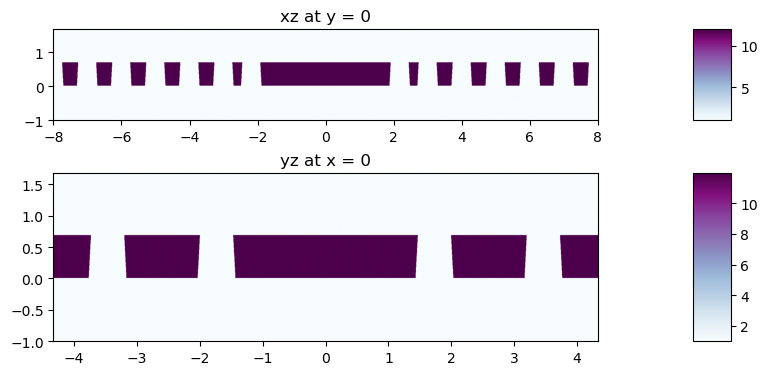

In [8]:
# Visualize the conical cavity (3 deg taper)
phc_viz = cavity_conical(3.0, n_slices=24)
legume.viz.structure(phc_viz, xz=True, yz=True, xy=False, figsize=8,
                     Nx=2000, Ny=2000, Nz=1000, cmap='BuPu')

## Convergence study: Q vs number of slices
Determine how many sub-layers are needed for converged results.

In [6]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_lb, 'gradients': 'approx', 'compute_im': False}

# Convergence test at 3 deg taper (all slices identical — Q should be stable)
n_slices_list = [2, 4, 8, 16, 24, 32]
Qs_conv = []
freqs_conv = []

print('Convergence study (taper = 3 deg):')
for ns in n_slices_list:
    phc_c = cavity_conical(3, n_slices=ns)
    gme_c = legume.GuidedModeExp(phc_c, gmax=gmax, truncate_g=truncate_g)
    gme_c.run(kpoints=np.array([[0], [0]]), **options)

    # Find L3 mode: candidates inside bandgap, pick highest Q
    all_freqs = gme_c.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_c.compute_rad(0, [c])
        Qc = gme_c.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    Qs_conv.append(best_Q)
    freqs_conv.append(gme_c.freqs[0, mind])
    print(f'  n_slices = {ns:2d},  Q = {best_Q:10.1f},  f = {gme_c.freqs[0, mind]:.5f}')

# Plot convergence
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_slices_list, Qs_conv, 'o-', lw=1.5, ms=6)
ax.set_xlabel('Number of sub-layers (n_slices)')
ax.set_ylabel('Q factor')
ax.set_title('Convergence: Q vs staircase resolution (taper = 3°)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Convergence study (taper = 3 deg):


KeyboardInterrupt: 

## Baseline: no taper (0 deg)

Modes near bandgap centre (bandgap: 0.2489 – 0.3274):
  Mode 0: f = 0.23944,  Q = 32592.5
  Mode 1: f = 0.24011,  Q = 2354.2
  Mode 2: f = 0.24064,  Q = 1301.9
  Mode 3: f = 0.24364,  Q = 14322.1
  Mode 4: f = 0.24373,  Q = 6165.9
  Mode 5: f = 0.24665,  Q = 41507.8
  Mode 6: f = 0.24741,  Q = 3056.3
  Mode 7: f = 0.24785,  Q = 17063.4
  Mode 8: f = 0.24827,  Q = 5380.8
  Mode 9: f = 0.25754,  Q = 198852.0 <-- IN BANDGAP

Baseline (0 deg taper): mode_idx = 9, f = 0.25754, Q = 198852.0


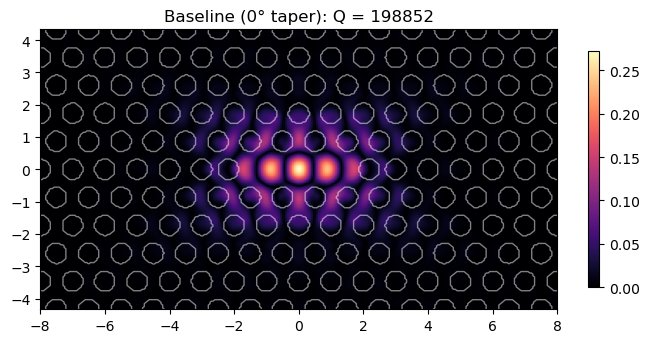

In [9]:
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_lb, 'gradients': 'approx', 'compute_im': False}

# Use the converged n_slices (even for 0 deg, to keep the layer count consistent)
n_slices = 24  # adjust based on convergence study above

phc_base = cavity_conical(0.0, n_slices=n_slices)
gme_base = legume.GuidedModeExp(phc_base, gmax=gmax, truncate_g=truncate_g)
gme_base.run(kpoints=np.array([[0], [0]]), **options)

# Identify L3 cavity mode: highest Q inside the bandgap
print(f'Modes near bandgap centre (bandgap: {f_lb:.4f} \u2013 {f_ub:.4f}):')
mode_idx = None
best_Q_base = -1
for i in range(gme_base.freqs.shape[1]):
    (freq_im_i, _, _) = gme_base.compute_rad(0, [i])
    Qi = gme_base.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme_base.freqs[0, i] < f_ub
    tag = ' <-- IN BANDGAP' if in_gap else ''
    print(f'  Mode {i}: f = {gme_base.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}')
    if in_gap and Qi > best_Q_base:
        best_Q_base = Qi
        mode_idx = i

if mode_idx is None:
    raise RuntimeError('No mode found inside the bandgap')

(freq_im, _, _) = gme_base.compute_rad(0, [mode_idx])
Q_base = gme_base.freqs[0, mode_idx] / (2 * freq_im[0])
f_base = gme_base.freqs[0, mode_idx]
print(f'\nBaseline (0 deg taper): mode_idx = {mode_idx}, f = {f_base:.5f}, Q = {Q_base:.1f}')

ax = legume.viz.field(gme_base, 'e', 0, mode_idx, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Baseline (0\u00b0 taper): Q = {Q_base:.0f}')
plt.show()

## Single conical run

In [11]:
# Single run at 3 deg taper
taper_test = 3.0  # degrees

phc_cone = cavity_conical(taper_test, n_slices=n_slices)
gme_cone = legume.GuidedModeExp(phc_cone, gmax=gmax, truncate_g=truncate_g)
gme_cone.run(kpoints=np.array([[0], [0]]),
             gmode_inds=[0], verbose=False, numeig=10,
             eig_sigma=f_base, gradients='approx', compute_im=False)

# Find L3 mode: highest Q inside the bandgap
all_freqs = gme_cone.freqs[0, :]
candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
best_Q, mind = -1, 0
for c in candidates:
    (fim, _, _) = gme_cone.compute_rad(0, [c])
    Qc = gme_cone.freqs[0, c] / (2 * fim[0])
    if Qc > best_Q:
        best_Q, mind = Qc, c

Q_cone = best_Q
f_cone = gme_cone.freqs[0, mind]

print(f'Taper = {taper_test} deg:  f = {f_cone:.5f},  Q = {Q_cone:.1f}')
print(f'Change from baseline:  \u0394f = {f_cone - f_base:.5f},  \u0394Q = {Q_cone - Q_base:.1f}')

ax = legume.viz.field(gme_cone, 'e', 0, mind, z=dslab/2,
                      component='y', val='abs', N1=300, N2=200)
plt.title(f'Taper = {taper_test}\u00b0: Q = {Q_cone:.0f}')
plt.show()

KeyboardInterrupt: 

## Q factor vs taper angle

In [9]:
# Sweep taper angle from 0 to 5 degrees
taper_angles = np.linspace(0, 5, 21)  # 0.25 deg steps
Qs_sweep = []
freqs_sweep = []

options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'gradients': 'approx', 'compute_im': False}

f_prev = f_base  # seed tracking

print('Sweeping taper angle:')
for angle in taper_angles:
    phc_s = cavity_conical(angle, n_slices=n_slices)
    gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
    gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep)

    # Find L3 mode: highest Q inside the bandgap
    all_freqs = gme_s.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    best_Q, mind = -1, 0
    for c in candidates:
        (fim, _, _) = gme_s.compute_rad(0, [c])
        Qc = gme_s.freqs[0, c] / (2 * fim[0])
        if Qc > best_Q:
            best_Q, mind = Qc, c

    f_s = gme_s.freqs[0, mind]
    f_prev = f_s

    Qs_sweep.append(best_Q)
    freqs_sweep.append(f_s)

    r_bot = ra - dslab * np.tan(np.radians(angle))
    print(f'  angle = {angle:5.2f} deg,  r_bot = {r_bot*a_nm:5.1f} nm,  '
          f'Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

print('Sweep complete.')

if SAVE_DATA:
    save_sweep('taper_angle', {
        'taper_angles': taper_angles,
        'Qs': np.array(Qs_sweep),
        'freqs': np.array(freqs_sweep),
    }, n_slices=n_slices)

Sweeping taper angle:
  angle =  0.00 deg,  r_bot =  75.0 nm,  Q =   198852.0,  f = 0.25754  (mode 8)
  angle =  0.25 deg,  r_bot =  74.3 nm,  Q =   197387.0,  f = 0.25723  (mode 8)
  angle =  0.50 deg,  r_bot =  73.5 nm,  Q =   188616.4,  f = 0.25693  (mode 8)
  angle =  0.75 deg,  r_bot =  72.8 nm,  Q =   174147.8,  f = 0.25663  (mode 8)
  angle =  1.00 deg,  r_bot =  72.0 nm,  Q =   156339.3,  f = 0.25635  (mode 8)
  angle =  1.25 deg,  r_bot =  71.3 nm,  Q =   137457.2,  f = 0.25606  (mode 8)
  angle =  1.50 deg,  r_bot =  70.5 nm,  Q =   119168.1,  f = 0.25579  (mode 8)
  angle =  1.75 deg,  r_bot =  69.8 nm,  Q =   102441.4,  f = 0.25552  (mode 8)
  angle =  2.00 deg,  r_bot =  69.1 nm,  Q =    87689.5,  f = 0.25525  (mode 8)
  angle =  2.25 deg,  r_bot =  68.3 nm,  Q =    74967.3,  f = 0.25499  (mode 8)
  angle =  2.50 deg,  r_bot =  67.6 nm,  Q =    64138.5,  f = 0.25474  (mode 8)
  angle =  2.75 deg,  r_bot =  66.8 nm,  Q =    54984.9,  f = 0.25449  (mode 8)
  angle =  3.00 de

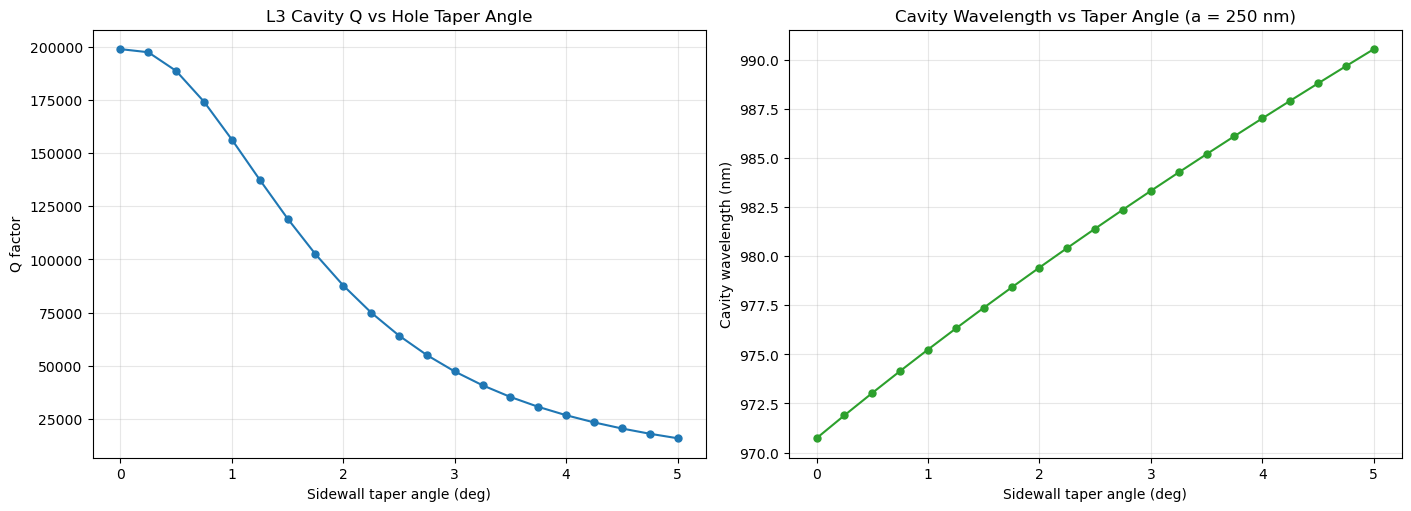

 angle (deg)  r_bot (nm)           Q    f (norm)   lambda (nm)
---------------------------------------------------------------------------
        0.00        75.0    198852.0     0.25754         970.7
        0.25        74.3    197387.0     0.25723         971.9
        0.50        73.5    188616.4     0.25693         973.0
        0.75        72.8    174147.8     0.25663         974.2
        1.00        72.0    156339.3     0.25635         975.2
        1.25        71.3    137457.2     0.25606         976.3
        1.50        70.5    119168.1     0.25579         977.4
        1.75        69.8    102441.4     0.25552         978.4
        2.00        69.1     87689.5     0.25525         979.4
        2.25        68.3     74967.3     0.25499         980.4
        2.50        67.6     64138.5     0.25474         981.4
        2.75        66.8     54984.9     0.25449         982.4
        3.00        66.1     47269.4     0.25424         983.3
        3.25        65.3     40767.4     0

In [10]:
# ── Plot sweep results ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Q vs taper angle
ax1.plot(taper_angles, Qs_sweep, 'o-', lw=1.5, ms=5)
ax1.set_xlabel('Sidewall taper angle (deg)')
ax1.set_ylabel('Q factor')
ax1.set_title('L3 Cavity Q vs Hole Taper Angle')
ax1.grid(True, alpha=0.3)

# Wavelength vs taper angle
lambdas_nm = [a_nm / f for f in freqs_sweep]
ax2.plot(taper_angles, lambdas_nm, 'o-', lw=1.5, ms=5, color='tab:green')
ax2.set_xlabel('Sidewall taper angle (deg)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Cavity Wavelength vs Taper Angle (a = {a_nm} nm)')
ax2.grid(True, alpha=0.3)

plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print('=' * 75)
print(f'{"angle (deg)":>12}  {"r_bot (nm)":>10}  {"Q":>10}  {"f (norm)":>10}  {"lambda (nm)":>12}')
print('-' * 75)
for ang, q, f, lam in zip(taper_angles, Qs_sweep, freqs_sweep, lambdas_nm):
    r_bot = ra - dslab * np.tan(np.radians(ang))
    print(f'{ang:>12.2f}  {r_bot*a_nm:>10.1f}  {q:>10.1f}  {f:>10.5f}  {lam:>12.1f}')
print('=' * 75)

## Combined sweep: Q vs taper angle for different hole radii

In [ ]:
# Combined sweep: taper angle for each hole radius
r_nm_list = [73, 74, 75, 76, 77]  # nm
taper_angles_r = np.linspace(0, 5, 11)  # deg
results_r = {}  # {r_nm: {'Qs': [...], 'freqs': [...]}}

options_sweep2 = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

for r_nm in r_nm_list:
    Qs, freqs = [], []
    f_prev = f_base  # re-seed for each radius

    print(f'\n--- r = {r_nm} nm ---')
    for angle in taper_angles_r:
        phc_s = cavity_conical(angle, n_slices=n_slices, r_nm=r_nm)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev, **options_sweep2)

        # Find L3 mode: highest Q inside the bandgap
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  angle = {angle:5.2f} deg,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_r[r_nm] = {'Qs': Qs, 'freqs': freqs}

print('\nCombined sweep complete.')

if SAVE_DATA:
    arrays = {'taper_angles': taper_angles_r, 'r_nm_list': np.array(r_nm_list)}
    for r_nm in r_nm_list:
        arrays[f'Qs_r{r_nm}'] = np.array(results_r[r_nm]['Qs'])
        arrays[f'freqs_r{r_nm}'] = np.array(results_r[r_nm]['freqs'])
    save_sweep('radius_taper', arrays, n_slices=n_slices, r_nm_list=r_nm_list)


--- r = 73 nm ---
  angle =  0.00 deg,  Q =   196090.6,  f = 0.25588  (mode 7)
  angle =  0.50 deg,  Q =   176890.3,  f = 0.25529  (mode 8)
  angle =  1.00 deg,  Q =   140774.6,  f = 0.25473  (mode 8)
  angle =  1.50 deg,  Q =   104156.8,  f = 0.25419  (mode 8)
  angle =  2.00 deg,  Q =    74953.6,  f = 0.25366  (mode 8)
  angle =  2.50 deg,  Q =    53842.8,  f = 0.25316  (mode 7)
  angle =  3.00 deg,  Q =    39067.7,  f = 0.25267  (mode 7)
  angle =  3.50 deg,  Q =    28755.0,  f = 0.25219  (mode 7)
  angle =  4.00 deg,  Q =    21492.0,  f = 0.25173  (mode 7)
  angle =  4.50 deg,  Q =    16327.5,  f = 0.25128  (mode 7)
  angle =  5.00 deg,  Q =    12686.8,  f = 0.25084  (mode 7)

--- r = 74 nm ---
  angle =  0.00 deg,  Q =   200981.8,  f = 0.25670  (mode 8)
  angle =  0.50 deg,  Q =   185007.2,  f = 0.25610  (mode 8)
  angle =  1.00 deg,  Q =   149612.6,  f = 0.25553  (mode 8)
  angle =  1.50 deg,  Q =   112046.0,  f = 0.25498  (mode 8)
  angle =  2.00 deg,  Q =    81414.5,  f = 0.25

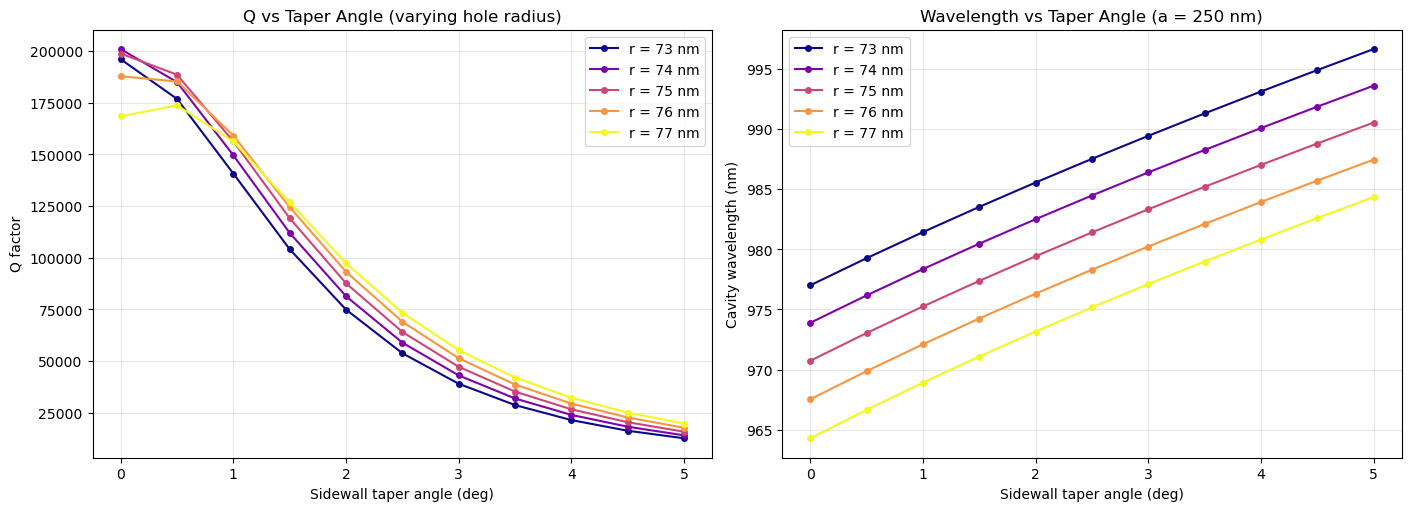

In [20]:
# ── Plot combined sweep results ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.plasma
colors = [cmap(i / (len(r_nm_list) - 1)) for i in range(len(r_nm_list))]

for i, r_nm in enumerate(r_nm_list):
    label = f'r = {r_nm} nm'
    ax1.plot(taper_angles_r, results_r[r_nm]['Qs'], 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_r[r_nm]['freqs']]
    ax2.plot(taper_angles_r, lambdas, 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])

ax1.set_xlabel('Sidewall taper angle (deg)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Taper Angle (varying hole radius)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Sidewall taper angle (deg)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Taper Angle (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Combined sweep: Q vs taper angle for different oxide thicknesses

In [12]:
# Sweep: taper angle for each oxide thickness (consume_ratio = 0.5)
t_ox_list = [0, 2, 4, 6, 8]  # nm
taper_angles_ox = np.linspace(0, 5, 11)  # deg
results_ox = {}

options_sweep_ox = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                    'gradients': 'approx', 'compute_im': False}

for t_ox_nm in t_ox_list:
    Qs, freqs = [], []
    f_prev = f_base

    print(f'\n--- t_ox = {t_ox_nm} nm ---')
    for angle in taper_angles_ox:
        phc_s = cavity_conical_oxidized(angle, t_ox_nm, consume_ratio=0.5,
                                        n_slices=n_slices)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev,
                  **options_sweep_ox)

        # Find L3 mode: highest Q inside the bandgap
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  angle = {angle:5.2f} deg,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_ox[t_ox_nm] = {'Qs': Qs, 'freqs': freqs}

print('\nOxide thickness sweep complete.')

if SAVE_DATA:
    arrays = {'taper_angles': taper_angles_ox, 't_ox_list': np.array(t_ox_list)}
    for t in t_ox_list:
        arrays[f'Qs_tox{t}'] = np.array(results_ox[t]['Qs'])
        arrays[f'freqs_tox{t}'] = np.array(results_ox[t]['freqs'])
    save_sweep('conical_oxide_sweep', arrays, consume_ratio=0.5, n_slices=n_slices)


--- t_ox = 0 nm ---
  angle =  0.00 deg,  Q =   198852.0,  f = 0.25754  (mode 8)
  angle =  0.50 deg,  Q =   188616.4,  f = 0.25693  (mode 8)
  angle =  1.00 deg,  Q =   156339.3,  f = 0.25635  (mode 8)
  angle =  1.50 deg,  Q =   119168.1,  f = 0.25579  (mode 8)
  angle =  2.00 deg,  Q =    87689.5,  f = 0.25525  (mode 8)
  angle =  2.50 deg,  Q =    64138.5,  f = 0.25474  (mode 8)
  angle =  3.00 deg,  Q =    47269.4,  f = 0.25424  (mode 8)
  angle =  3.50 deg,  Q =    35279.9,  f = 0.25376  (mode 8)
  angle =  4.00 deg,  Q =    26694.7,  f = 0.25329  (mode 7)
  angle =  4.50 deg,  Q =    20464.1,  f = 0.25283  (mode 7)
  angle =  5.00 deg,  Q =    15872.2,  f = 0.25239  (mode 7)

--- t_ox = 2 nm ---
  angle =  0.00 deg,  Q =   189342.5,  f = 0.25845  (mode 8)
  angle =  0.50 deg,  Q =   185041.6,  f = 0.25783  (mode 8)
  angle =  1.00 deg,  Q =   159376.7,  f = 0.25724  (mode 8)
  angle =  1.50 deg,  Q =   126125.0,  f = 0.25668  (mode 8)
  angle =  2.00 deg,  Q =    95867.1,  f = 

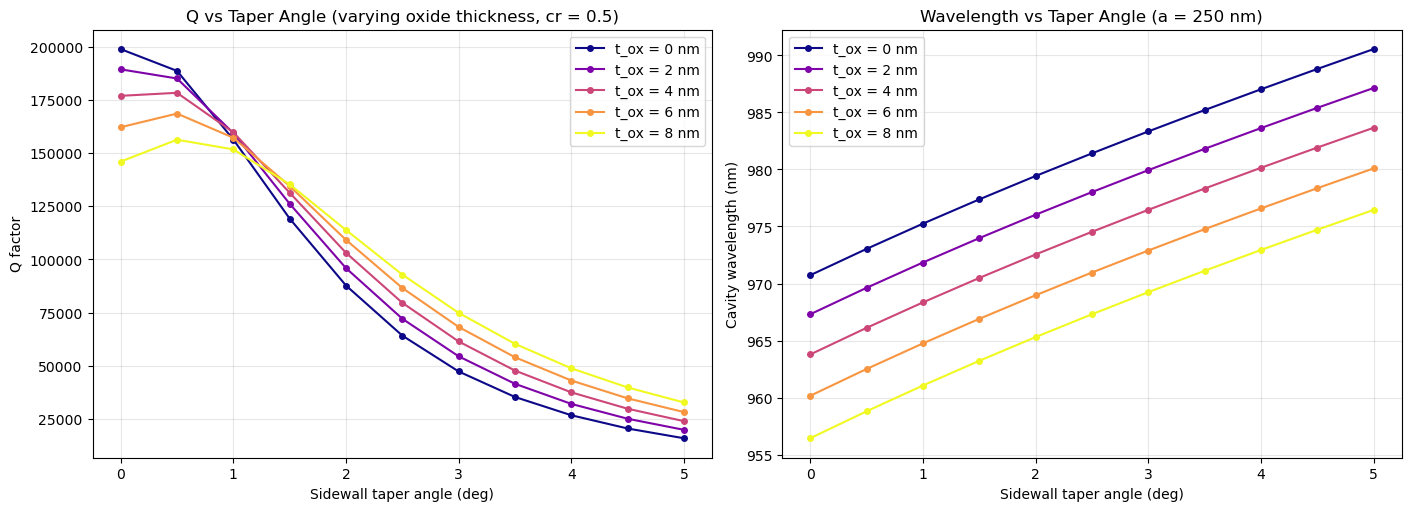

In [13]:
# ── Plot oxide thickness sweep results ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.plasma
colors = [cmap(i / (len(t_ox_list) - 1)) for i in range(len(t_ox_list))]

for i, t_ox_nm in enumerate(t_ox_list):
    label = f't_ox = {t_ox_nm} nm'
    ax1.plot(taper_angles_ox, results_ox[t_ox_nm]['Qs'], 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_ox[t_ox_nm]['freqs']]
    ax2.plot(taper_angles_ox, lambdas, 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])

ax1.set_xlabel('Sidewall taper angle (deg)')
ax1.set_ylabel('Q factor')
ax1.set_title('Q vs Taper Angle (varying oxide thickness, cr = 0.5)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Sidewall taper angle (deg)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Taper Angle (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Combined sweep: Q vs taper angle for different consume ratios

In [14]:
# Sweep: taper angle for each consume ratio (fixed t_ox = 5 nm)
t_ox_fixed = 5  # nm
cr_list = np.linspace(0.4, 1.0, 4)
taper_angles_cr = np.linspace(0, 5, 11)  # deg
results_cr = {}

options_sweep_cr = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                    'gradients': 'approx', 'compute_im': False}

for cr in cr_list:
    Qs, freqs = [], []
    f_prev = f_base

    print(f'\n--- consume_ratio = {cr:.2f} ---')
    for angle in taper_angles_cr:
        phc_s = cavity_conical_oxidized(angle, t_ox_fixed, consume_ratio=cr,
                                        n_slices=n_slices)
        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev,
                  **options_sweep_cr)

        # Find L3 mode: highest Q inside the bandgap
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > best_Q:
                best_Q, mind = Qc, c

        f_s = gme_s.freqs[0, mind]
        f_prev = f_s
        Qs.append(best_Q)
        freqs.append(f_s)
        print(f'  angle = {angle:5.2f} deg,  Q = {best_Q:10.1f},  f = {f_s:.5f}  (mode {mind})')

    results_cr[cr] = {'Qs': Qs, 'freqs': freqs}

print('\nConsume ratio sweep complete.')

if SAVE_DATA:
    arrays = {'taper_angles': taper_angles_cr, 'cr_list': np.array(cr_list)}
    for cr in cr_list:
        arrays[f'Qs_cr{cr:.2f}'] = np.array(results_cr[cr]['Qs'])
        arrays[f'freqs_cr{cr:.2f}'] = np.array(results_cr[cr]['freqs'])
    save_sweep('conical_consume_ratio', arrays,
               t_ox_nm=t_ox_fixed, n_slices=n_slices, cr_list=cr_list.tolist())


--- consume_ratio = 0.40 ---


KeyboardInterrupt: 

In [ ]:
# ── Plot consume ratio sweep results ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cmap = plt.cm.plasma
colors = [cmap(i / (len(cr_list) - 1)) for i in range(len(cr_list))]

for i, cr in enumerate(cr_list):
    label = f'cr = {cr:.1f}'
    ax1.plot(taper_angles_cr, results_cr[cr]['Qs'], 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])
    lambdas = [a_nm / f for f in results_cr[cr]['freqs']]
    ax2.plot(taper_angles_cr, lambdas, 'o-', ms=4, lw=1.5,
             label=label, color=colors[i])

ax1.set_xlabel('Sidewall taper angle (deg)')
ax1.set_ylabel('Q factor')
ax1.set_title(f'Q vs Taper Angle (varying consume ratio, t_ox = {t_ox_fixed} nm)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Sidewall taper angle (deg)')
ax2.set_ylabel('Cavity wavelength (nm)')
ax2.set_title(f'Wavelength vs Taper Angle (a = {a_nm} nm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

## Piecewise-taper heatmap: independent top/bottom sidewall angles
Explore barrel (wider in middle) and hourglass (narrower in middle) hole profiles
by varying the sidewall taper angle independently at each slab surface.

In [11]:
def cavity_piecewise_taper(angle_top_deg, angle_bottom_deg, n_slices=24, r_nm=None):
    """Build an L3 cavity with piecewise-linear tapered holes.

    The hole radius varies independently in the top and bottom halves of the
    slab, allowing barrel, hourglass, and asymmetric profiles.

    Profile:
      Top half  (z in [0, dslab/2]):      r(z) = ra - z * tan(angle_top)
      Bottom half (z in [dslab/2, dslab]): r(z) = ra - (dslab-z) * tan(angle_bottom)

    Parameters
    ----------
    angle_top_deg : float
        Sidewall taper from vertical at the top surface (deg).
        Positive = narrows going down.
    angle_bottom_deg : float
        Sidewall taper from vertical at the bottom surface (deg).
        Positive = narrows going up.
    n_slices : int
        Number of sub-layers for staircase approximation.
    r_nm : float or None
        Hole radius in nm. If None, uses global `ra`.
    """
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    tan_top = np.tan(np.radians(angle_top_deg))
    tan_bot = np.tan(np.radians(angle_bottom_deg))

    d_slice = dslab / n_slices

    # Pre-compute radii and validate
    r_slices = []
    for k in range(n_slices):
        z_center = (k + 0.5) * d_slice
        if z_center <= dslab / 2:
            r_k = r_a - z_center * tan_top
        else:
            r_k = r_a - (dslab - z_center) * tan_bot
        r_slices.append(r_k)

    if min(r_slices) <= 0:
        raise ValueError(
            f'Radius goes to zero: min r = {min(r_slices)*a_nm:.1f} nm '
            f'(top={angle_top_deg} deg, bot={angle_bottom_deg} deg)')

    phc = legume.PhotCryst(lattice)

    for k in range(n_slices):
        phc.add_layer(d=d_slice, eps_b=n_slab**2)

        for ic in range(nc):
            yc = yp[ic]
            xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

            positions = [(xc, yc)]
            if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
                positions.append((-xc, -yc))
            if nx-1.6 > xp[ic] > 0:
                positions.append((-xc, yc))
            if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
                positions.append((xc, -yc))

            for (px, py) in positions:
                phc.add_shape(Circle(x_cent=px, y_cent=py, r=r_slices[k]),
                              layer=k)

    return phc


Hourglass (5°, 5°)

Barrel (-5°, -5°)


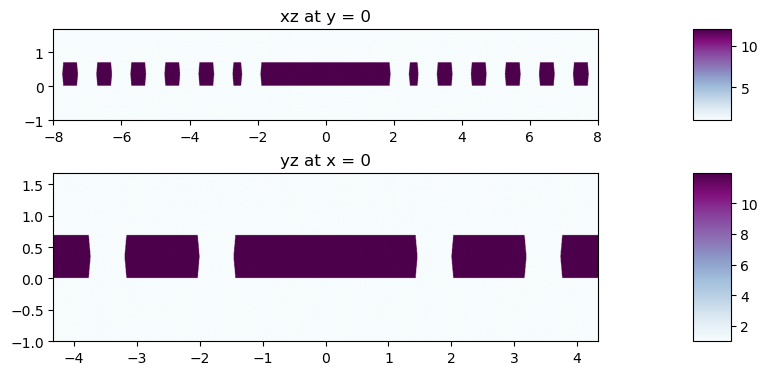

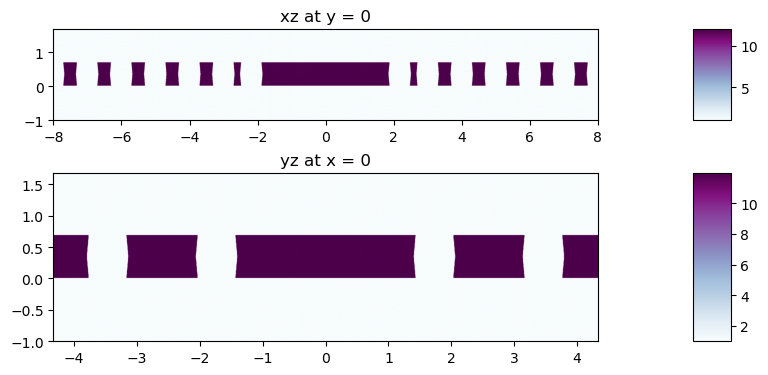

In [16]:
# Visualize key piecewise-taper profiles
fig_titles = [
    ('Hourglass (5°, 5°)',  5.0, 5.0),
    ('Barrel (-5°, -5°)', -5.0, -5.0),
]

for title, a_top, a_bot in fig_titles:
    phc_viz = cavity_piecewise_taper(a_top, a_bot, n_slices=n_slices)
    print(f'\n{title}')
    legume.viz.structure(phc_viz, xz=True, yz=True, xy=False, figsize=8,
                         Nx=3000, Ny=2500, Nz=2000, cmap='BuPu')

In [12]:
# 2D heatmap sweep: angle_top vs angle_bottom
# Quick test grid (switch to np.linspace(-3, 5, 17) for full resolution)
angles = np.linspace(-3, 5, 9)  # 1 deg steps, 9 points -> 45 runs
n_angles = len(angles)

Q_matrix = np.full((n_angles, n_angles), np.nan)
f_matrix = np.full((n_angles, n_angles), np.nan)

options_heatmap = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                   'gradients': 'approx', 'compute_im': False}

total = n_angles * (n_angles + 1) // 2
count = 0

print(f'Piecewise-taper heatmap: {total} runs ({n_angles}x{n_angles}, upper triangle)')
for i, a_top in enumerate(angles):
    f_prev = f_base  # re-seed each row

    for j, a_bot in enumerate(angles):
        if j > i:
            continue  # fill by symmetry
        count += 1

        try:
            phc_s = cavity_piecewise_taper(a_top, a_bot, n_slices=n_slices)
        except ValueError as e:
            print(f'  [{count:3d}/{total}] top={a_top:+5.1f}, bot={a_bot:+5.1f} deg  SKIPPED ({e})')
            continue

        gme_s = legume.GuidedModeExp(phc_s, gmax=gmax, truncate_g=truncate_g)
        gme_s.run(kpoints=np.array([[0], [0]]), eig_sigma=f_prev,
                  **options_heatmap)

        # Find L3 mode: highest Q inside the bandgap
        all_freqs = gme_s.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        best_Q, mind = -1, 0
        for c in candidates:
            (fim, _, _) = gme_s.compute_rad(0, [c])
            Qc = gme_s.freqs[0, c] / (2 * fim[0])
            if Qc > 0 and Qc > best_Q:
                best_Q, mind = Qc, c

        if best_Q > 0:
            f_s = gme_s.freqs[0, mind]
            f_prev = f_s
            Q_matrix[i, j] = best_Q
            f_matrix[i, j] = f_s
            if i != j:
                Q_matrix[j, i] = best_Q
                f_matrix[j, i] = f_s

        print(f'  [{count:3d}/{total}] top={a_top:+5.1f}, bot={a_bot:+5.1f} deg  '
              f'Q={best_Q:10.1f}  f={gme_s.freqs[0, mind]:.5f}')

print('\nHeatmap sweep complete.')

if SAVE_DATA:
    save_sweep('piecewise_taper_heatmap', {
        'angles': angles,
        'Q_matrix': Q_matrix,
        'f_matrix': f_matrix,
    }, n_slices=n_slices, angle_range=f'{angles[0]} to {angles[-1]} deg',
       n_angles=n_angles)

Piecewise-taper heatmap: 45 runs (9x9, upper triangle)
  [  1/45] top= -3.0, bot= -3.0 deg  Q=  148106.9  f=0.25957
  [  2/45] top= -2.0, bot= -3.0 deg  Q=  153790.0  f=0.25923
  [  3/45] top= -2.0, bot= -2.0 deg  Q=  169029.0  f=0.25887
  [  4/45] top= -1.0, bot= -3.0 deg  Q=  148587.3  f=0.25893
  [  5/45] top= -1.0, bot= -2.0 deg  Q=  172136.8  f=0.25854
  [  6/45] top= -1.0, bot= -1.0 deg  Q=  186404.4  f=0.25819
  [  7/45] top= +0.0, bot= -3.0 deg  Q=  135220.6  f=0.25867
  [  8/45] top= +0.0, bot= -2.0 deg  Q=  162681.0  f=0.25825
  [  9/45] top= +0.0, bot= -1.0 deg  Q=  186348.7  f=0.25788
  [ 10/45] top= +0.0, bot= +0.0 deg  Q=  198852.0  f=0.25754
  [ 11/45] top= +1.0, bot= -3.0 deg  Q=  118151.3  f=0.25844
  [ 12/45] top= +1.0, bot= -2.0 deg  Q=  144969.4  f=0.25800
  [ 13/45] top= +1.0, bot= -1.0 deg  Q=  172807.7  f=0.25760
  [ 14/45] top= +1.0, bot= +0.0 deg  Q=  195635.8  f=0.25724
  [ 15/45] top= +1.0, bot= +1.0 deg  Q=  206034.4  f=0.25691
  [ 16/45] top= +2.0, bot= -3.

Loading from: data/2026-03-26_181204_piecewise_taper_heatmap


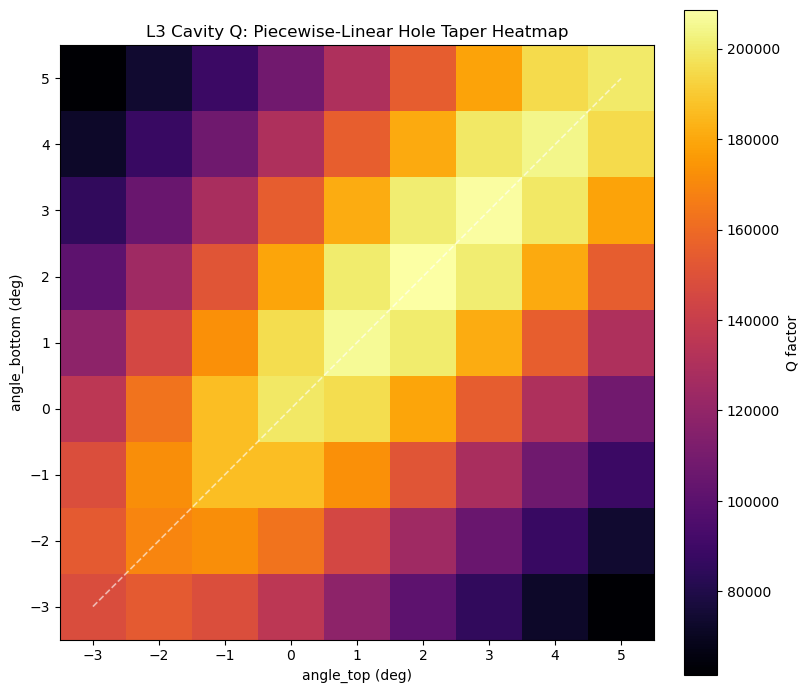

In [2]:
# ── Piecewise-taper heatmap plot ───────────────────────────────────────────
import glob, os
from matplotlib.colors import LogNorm

# Load most recent heatmap sweep
folders = sorted(glob.glob('data/*_piecewise_taper_heatmap'))
if not folders:
    raise FileNotFoundError('No piecewise_taper_heatmap data found in data/. Run the sweep cell first.')
folder = folders[-1]
print(f'Loading from: {folder}')

angles   = np.load(os.path.join(folder, 'angles.npy'))
Q_matrix = np.load(os.path.join(folder, 'Q_matrix.npy'))

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)

# Bin edges for pcolormesh
da = angles[1] - angles[0]
edges = np.append(angles - da/2, angles[-1] + da/2)

# Log scale if Q spans > 2 orders of magnitude
Q_valid = Q_matrix[Q_matrix > 0]
use_log = (Q_valid.max() / Q_valid.min() > 100) if len(Q_valid) > 0 else False
norm = LogNorm(vmin=Q_valid.min(), vmax=Q_valid.max()) if use_log else None

pcm = ax.pcolormesh(edges, edges, Q_matrix, cmap='inferno', shading='flat', norm=norm)
fig.colorbar(pcm, ax=ax, label='Q factor')

# Diagonal line: angle_top == angle_bottom (no legend entry)
ax.plot([angles[0], angles[-1]], [angles[0], angles[-1]], 'w--', lw=1.2, alpha=0.6)

ax.set_xlabel('angle_top (deg)')
ax.set_ylabel('angle_bottom (deg)')
ax.set_title('L3 Cavity Q: Piecewise-Linear Hole Taper Heatmap')
ax.set_aspect('equal')

plt.show()

## Elliptical holes: effect of hole ellipticity on Q

Replace every circular hole with an ellipse of the same area.  
Ellipticity $e = r_y / r_x$; area is preserved via $r_x r_y = r^2$, so
$r_x = r/\sqrt{e}$, $r_y = r\sqrt{e}$.  
$e = 1$: circular &nbsp;|&nbsp; $e > 1$: elongated along $y$ ($\Gamma$-M) &nbsp;|&nbsp; $e < 1$: elongated along $x$ (cavity axis).

In [15]:
from legume import Ellipse

def cavity_elliptical(ellipticity, phi_deg=0, r_nm=None):
    """Build an L3 cavity with elliptical holes (constant area).

    Parameters
    ----------
    ellipticity : float
        Ratio ry/rx.  1.0 = circular.
        > 1 elongated along y (Gamma-M), < 1 elongated along x (cavity axis).
    phi_deg : float
        Rotation angle of every ellipse in degrees.
    r_nm : float or None
        Hole radius in nm (sets area = pi*r^2). Defaults to global ra.
    """
    r_a = (r_nm / a_nm) if r_nm is not None else ra
    rx = r_a / np.sqrt(ellipticity)
    ry = r_a * np.sqrt(ellipticity)
    phi = np.radians(phi_deg)

    phc = legume.PhotCryst(lattice)
    phc.add_layer(d=dslab, eps_b=n_slab**2)

    for ic in range(nc):
        yc = yp[ic]
        xc = xp[ic] + dx[ic] if xp[ic] != 0 else 0.0

        positions = [(xc, yc)]
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            positions.append((-xc, -yc))
        if nx-1.6 > xp[ic] > 0:
            positions.append((-xc, yc))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            positions.append((xc, -yc))

        for (px, py) in positions:
            phc.add_shape(Ellipse(x_cent=px, y_cent=py, rx=rx, ry=ry, phi=phi),
                          layer=0)

    return phc

# Show semi-axis values for a few ellipticities
print(f'Hole radius: r = {ra:.4f}a = {ra*a_nm:.1f} nm')
print(f'{"e":>6s}  {"rx (nm)":>8s}  {"ry (nm)":>8s}  {"area check":>10s}')
for e in [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]:
    rxe = ra / np.sqrt(e)
    rye = ra * np.sqrt(e)
    print(f'{e:6.2f}  {rxe*a_nm:8.1f}  {rye*a_nm:8.1f}  {np.pi*rxe*rye*a_nm**2:10.1f}')

Hole radius: r = 0.3000a = 75.0 nm
     e   rx (nm)   ry (nm)  area check
  0.70      89.6      62.7     17671.5
  0.80      83.9      67.1     17671.5
  0.90      79.1      71.2     17671.5
  1.00      75.0      75.0     17671.5
  1.10      71.5      78.7     17671.5
  1.20      68.5      82.2     17671.5
  1.30      65.8      85.5     17671.5



e = 0.6 (x-elongated):  rx = 83.9 nm,  ry = 67.1 nm


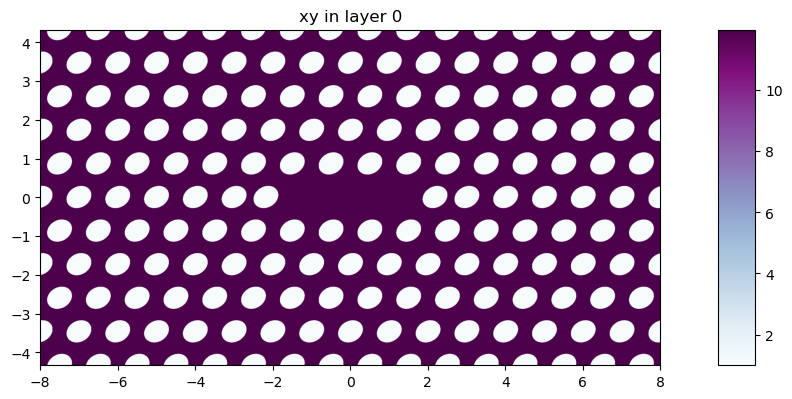

In [26]:
# Visualize representative ellipticities and a rotated case
viz_cases = [
    ('e = 0.6 (x-elongated)',          0.8,  30),
]

for title, e, phi in viz_cases:
    phc_viz = cavity_elliptical(e, phi_deg=phi)
    rx_nm = ra / np.sqrt(e) * a_nm
    ry_nm = ra * np.sqrt(e) * a_nm
    print(f'\n{title}:  rx = {rx_nm:.1f} nm,  ry = {ry_nm:.1f} nm')
    legume.viz.structure(phc_viz, figsize=8, Nx=2000, Ny=2000, cmap='BuPu')

### Q factor vs ellipticity

In [ ]:
# Sweep ellipticity (constant hole area) — outward from e=1.0
ellipticities = np.linspace(0.6, 1.6, 21)
i_base = np.argmin(np.abs(ellipticities - 1.0))  # start here

Qs_ellip = np.full(len(ellipticities), np.nan)
freqs_ellip = np.full(len(ellipticities), np.nan)

options_ellip = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                  'gradients': 'approx', 'compute_im': False}

def _run_ellip(idx, f_prev_val):
    e = ellipticities[idx]
    phc_e = cavity_elliptical(e)
    gme_e = legume.GuidedModeExp(phc_e, gmax=gmax, truncate_g=truncate_g)
    gme_e.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_ellip)

    all_freqs = gme_e.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    if len(candidates) == 0:
        print(f'  e = {e:5.2f}  NO MODE IN BANDGAP')
        return f_prev_val

    freq_dists = np.abs(all_freqs[candidates] - f_prev_val)
    mind = candidates[np.argmin(freq_dists)]
    (fim, _, _) = gme_e.compute_rad(0, [mind])
    best_Q = gme_e.freqs[0, mind] / (2 * fim[0])
    f_e = gme_e.freqs[0, mind]

    Qs_ellip[idx] = best_Q
    freqs_ellip[idx] = f_e

    rxe = ra / np.sqrt(e)
    rye = ra * np.sqrt(e)
    print(f'  e = {e:5.2f}  rx = {rxe*a_nm:5.1f} nm  ry = {rye*a_nm:5.1f} nm  '
          f'Q = {best_Q:10.1f}  f = {f_e:.5f}')
    return f_e

# Forward sweep: e=1.0 → 1.6
print('Sweeping ellipticity (outward from e=1.0):')
print('--- Forward (e=1.0 -> 1.6) ---')
f_prev = f_base
for idx in range(i_base, len(ellipticities)):
    f_prev = _run_ellip(idx, f_prev)

# Backward sweep: e<1.0 → 0.6
print('--- Backward (e=1.0 -> 0.6) ---')
f_prev = f_base
for idx in range(i_base - 1, -1, -1):
    f_prev = _run_ellip(idx, f_prev)

print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('ellipticity', {
        'ellipticities': ellipticities,
        'Qs': Qs_ellip,
        'freqs': freqs_ellip,
    }, r_nm=ra*a_nm)

Loading from: data/2026-04-01_100348_ellipticity


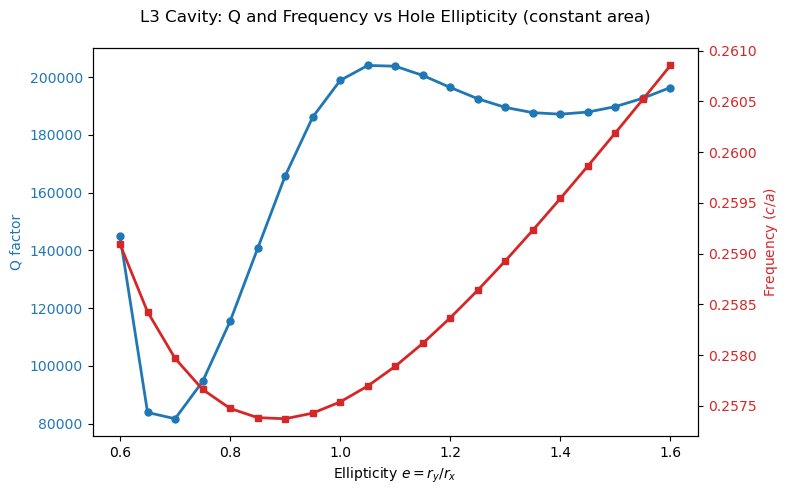

In [18]:
# ── Ellipticity sweep plot ────────────────────────────────────────────────
import glob, os

folders = sorted(glob.glob('data/*_ellipticity'))
if not folders:
    raise FileNotFoundError('No ellipticity data found in data/. Run the sweep cell first.')
folder = folders[-1]
print(f'Loading from: {folder}')

ellipticities = np.load(os.path.join(folder, 'ellipticities.npy'))
Qs_ellip      = np.load(os.path.join(folder, 'Qs.npy'))
freqs_ellip   = np.load(os.path.join(folder, 'freqs.npy'))

fig, ax1 = plt.subplots(figsize=(8, 5))

color_q = '#1f77b4'
color_f = '#d62728'

ax1.plot(ellipticities, Qs_ellip, 'o-', color=color_q, lw=2, ms=5)
ax1.set_xlabel('Ellipticity $e = r_y / r_x$')
ax1.set_ylabel('Q factor', color=color_q)
ax1.tick_params(axis='y', labelcolor=color_q)

ax2 = ax1.twinx()
ax2.plot(ellipticities, freqs_ellip, 's-', color=color_f, lw=2, ms=4)
ax2.set_ylabel('Frequency ($c/a$)', color=color_f)
ax2.tick_params(axis='y', labelcolor=color_f)

fig.suptitle('L3 Cavity: Q and Frequency vs Hole Ellipticity (constant area)')
fig.tight_layout()
plt.show()

### Understanding ellipticity and rotation angle

Each circular hole (radius $r$) is replaced by an ellipse with semi-axes $r_x$ and $r_y$,
keeping the **area constant**: $\pi r_x r_y = \pi r^2$.

**Ellipticity** $e = r_y / r_x$:

| $e$ | Shape | Semi-axes |
|-----|-------|-----------|
| $e = 1$ | Circle | $r_x = r_y = r$ |
| $e > 1$ | Elongated along $y$ | $r_x = r/\sqrt{e}$ (narrow), $r_y = r\sqrt{e}$ (wide) |
| $e < 1$ | Elongated along $x$ | $r_x = r/\sqrt{e}$ (wide), $r_y = r\sqrt{e}$ (narrow) |

**Rotation angle** $\phi$: rotates the ellipse by $\phi$ degrees **counter-clockwise** from its default orientation. Only the hole shape rotates — the lattice positions stay fixed.

**Equivalences:**  
An ellipse with $(e,\, \phi)$ has the *same shape* as $(1/e,\, \phi + 90°)$ — swapping the axes and rotating 90° gives the identical geometry.

For the L3 cavity (cavity axis along $x$, i.e. $\Gamma$-K):

| Configuration | Physical meaning |
|---------------|------------------|
| $e > 1$, $\phi = 0°$ | Holes elongated **perpendicular** to cavity axis |
| $e < 1$, $\phi = 0°$ | Holes elongated **along** cavity axis |
| $e \neq 1$, $0° < \phi < 90°$ | Holes tilted at an angle to the cavity axis |
| $e = 1$ (any $\phi$) | Circular — $\phi$ has no effect |

**What to expect from the diagnostics below:**  
$(e=1.3,\, \phi=0°)$ and $(e=1/1.3,\, \phi=90°)$ describe the **same physical ellipse** and should give identical Q and frequency. If they don't, there is a bug in the geometry or solver.

### Field diagnostics: verify geometry and mode for selected (e, phi) pairs

Pairs that should be physically equivalent are grouped together for comparison.  
e.g. `(e, 0°)` vs `(1/e, 90°)` should give the same shape rotated 90°.

In [ ]:
# Field diagnostics for selected elliptical configurations
diag_cases = [
    # (label, ellipticity, phi_deg)
    ('e=1.3, phi=0',     1.3,    0),
    ('e=1/1.3, phi=90',  1/1.3, 90),   # should match e=1.3, phi=0
    ('e=0.7, phi=0',     0.7,    0),
    ('e=1/0.7, phi=90',  1/0.7, 90),   # should match e=0.7, phi=0
]

options_diag = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                'gradients': 'approx', 'compute_im': False}

for label, e, phi in diag_cases:
    rx_nm = ra / np.sqrt(e) * a_nm
    ry_nm = ra * np.sqrt(e) * a_nm
    print(f'\n{"="*60}')
    print(f'{label}:  rx = {rx_nm:.1f} nm,  ry = {ry_nm:.1f} nm,  phi = {phi} deg')
    print(f'{"="*60}')

    phc_d = cavity_elliptical(e, phi_deg=phi)
    gme_d = legume.GuidedModeExp(phc_d, gmax=gmax, truncate_g=truncate_g)
    gme_d.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_diag)

    # Track mode by frequency continuity (closest to f_base)
    all_freqs = gme_d.freqs[0, :]
    candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
    freq_dists = np.abs(all_freqs[candidates] - f_base)
    mind = candidates[np.argmin(freq_dists)]
    (fim, _, _) = gme_d.compute_rad(0, [mind])
    best_Q = gme_d.freqs[0, mind] / (2 * fim[0])

    print(f'Mode {mind}: f = {gme_d.freqs[0, mind]:.5f},  Q = {best_Q:.1f}')

    # Structure xy
    print(f'\nStructure: {label}')
    legume.viz.structure(phc_d, figsize=6, Nx=800, Ny=800, cmap='BuPu')

    # Ey field
    ax_f = legume.viz.field(gme_d, 'e', 0, mind, z=dslab/2,
                            component='y', val='abs', N1=300, N2=200)
    plt.title(f'|Ey|: Q = {best_Q:.0f},  f = {gme_d.freqs[0, mind]:.5f}')
    plt.show()

### Q vs ellipticity and rotation angle

In [ ]:
# 2D sweep: ellipticity vs rotation angle — ellipticity swept outward from 1.0
ellipticities_2d = np.linspace(0.7, 1.4, 8)
phi_degs = np.linspace(0, 90, 10)
n_e = len(ellipticities_2d)
n_phi = len(phi_degs)
i_base_2d = np.argmin(np.abs(ellipticities_2d - 1.0))

Q_map = np.full((n_e, n_phi), np.nan)
f_map = np.full((n_e, n_phi), np.nan)

options_er = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
               'gradients': 'approx', 'compute_im': False}

def _run_er(i_e, f_seed):
    e = ellipticities_2d[i_e]
    f_prev = f_seed
    for i_phi, phi in enumerate(phi_degs):
        phc_er = cavity_elliptical(e, phi_deg=phi)
        gme_er = legume.GuidedModeExp(phc_er, gmax=gmax, truncate_g=truncate_g)
        gme_er.run(kpoints=np.array([[0], [0]]), eig_sigma=f_base, **options_er)

        all_freqs = gme_er.freqs[0, :]
        candidates = np.where((all_freqs > f_lb) & (all_freqs < f_ub))[0]
        if len(candidates) == 0:
            print(f'  e={e:5.2f}  phi={phi:5.1f} deg  NO MODE')
            continue

        freq_dists = np.abs(all_freqs[candidates] - f_prev)
        mind = candidates[np.argmin(freq_dists)]
        (fim, _, _) = gme_er.compute_rad(0, [mind])
        best_Q = gme_er.freqs[0, mind] / (2 * fim[0])

        if best_Q > 0:
            f_er = gme_er.freqs[0, mind]
            f_prev = f_er
            Q_map[i_e, i_phi] = best_Q
            f_map[i_e, i_phi] = f_er

        print(f'  e={e:5.2f}  phi={phi:5.1f} deg  '
              f'Q={best_Q:10.1f}  f={gme_er.freqs[0, mind]:.5f}')
    # Return phi=0 frequency as seed for next ellipticity step
    return f_map[i_e, 0] if not np.isnan(f_map[i_e, 0]) else f_seed

total = n_e * n_phi
print(f'Ellipticity x rotation sweep: {total} runs ({n_e} x {n_phi}), outward from e=1.0')

# Forward: e near 1.0 -> 1.4
print('--- Forward ---')
f_seed = f_base
for i_e in range(i_base_2d, n_e):
    f_seed = _run_er(i_e, f_seed)

# Backward: e near 1.0 -> 0.7
print('--- Backward ---')
f_seed = f_base
for i_e in range(i_base_2d - 1, -1, -1):
    f_seed = _run_er(i_e, f_seed)

print('\nSweep complete.')

if SAVE_DATA:
    save_sweep('ellipticity_rotation', {
        'ellipticities': ellipticities_2d,
        'phi_degs': phi_degs,
        'Q_map': Q_map,
        'f_map': f_map,
    }, r_nm=ra*a_nm)

Loading from: data/2026-04-01_103009_ellipticity_rotation


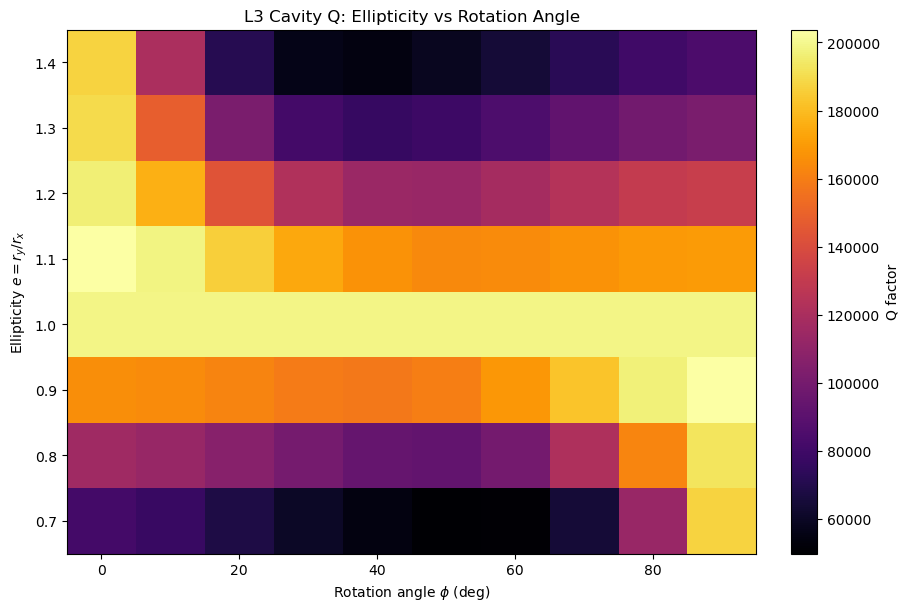

In [21]:
# ── Ellipticity x rotation heatmap plot ───────────────────────────────────
import glob, os
from matplotlib.colors import LogNorm

folders = sorted(glob.glob('data/*_ellipticity_rotation'))
if not folders:
    raise FileNotFoundError('No ellipticity_rotation data found in data/.')
folder = folders[-1]
print(f'Loading from: {folder}')

ellipticities_2d = np.load(os.path.join(folder, 'ellipticities.npy'))
phi_degs         = np.load(os.path.join(folder, 'phi_degs.npy'))
Q_map            = np.load(os.path.join(folder, 'Q_map.npy'))

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)

# Bin edges
de = ellipticities_2d[1] - ellipticities_2d[0]
dp = phi_degs[1] - phi_degs[0]
e_edges = np.append(ellipticities_2d - de/2, ellipticities_2d[-1] + de/2)
p_edges = np.append(phi_degs - dp/2, phi_degs[-1] + dp/2)

Q_valid = Q_map[Q_map > 0]
use_log = (Q_valid.max() / Q_valid.min() > 1000000) if len(Q_valid) > 0 else False
norm = LogNorm(vmin=Q_valid.min(), vmax=Q_valid.max()) if use_log else None

pcm = ax.pcolormesh(p_edges, e_edges, Q_map, cmap='inferno', shading='flat',
                    norm=norm)
fig.colorbar(pcm, ax=ax, label='Q factor')

# Horizontal line at e = 1.0 (circular — rotation irrelevant)
#ax.axhline(1.0, color='white', ls='--', lw=1.2, alpha=0.6)

ax.set_xlabel('Rotation angle $\\phi$ (deg)')
ax.set_ylabel('Ellipticity $e = r_y / r_x$')
ax.set_title('L3 Cavity Q: Ellipticity vs Rotation Angle')

plt.show()

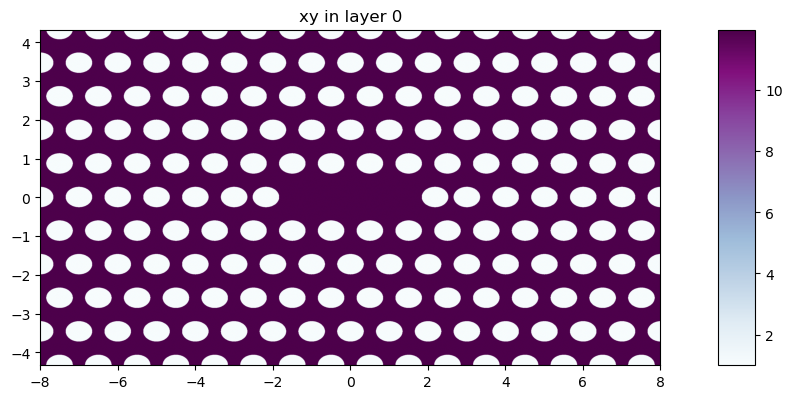

In [30]:
# Visualize three representative ellipticities

phc_viz = cavity_elliptical(1.3, phi_deg=90)
legume.viz.structure(phc_viz, figsize=8, Nx=2000, Ny=2000, cmap='BuPu')